In [1]:
# Install if needed:
# pip install pandas pyarrow numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [2]:
# ==========================================================
# 2. LOAD DATASET
# ==========================================================
df = pd.read_parquet("Obfuscated-MalMem2022.parquet")

print("Dataset Loaded Successfully")
print(df.head())
print("Shape:", df.shape)

Dataset Loaded Successfully
  Category  pslist.nproc  pslist.nppid  pslist.avg_threads  \
0   Benign            45            17           10.555555   
1   Benign            47            19           11.531915   
2   Benign            40            14           14.725000   
3   Benign            32            13           13.500000   
4   Benign            42            16           11.452381   

   pslist.nprocs64bit  pslist.avg_handlers  dlllist.ndlls  \
0                   0           202.844452           1694   
1                   0           242.234039           2074   
2                   0           288.225006           1932   
3                   0           264.281250           1445   
4                   0           281.333344           2067   

   dlllist.avg_dlls_per_proc  handles.nhandles  handles.avg_handles_per_proc  \
0                  38.500000              9129                    212.302322   
1                  44.127659             11385                    242.23

In [3]:
# ==========================================================
# 3. BASIC INFO
# ==========================================================
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["Class"].value_counts())

print("\nCategory Distribution:")
print(df["Category"].value_counts().head(10))


Columns:
['Category', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.not_in_ethread_pool_

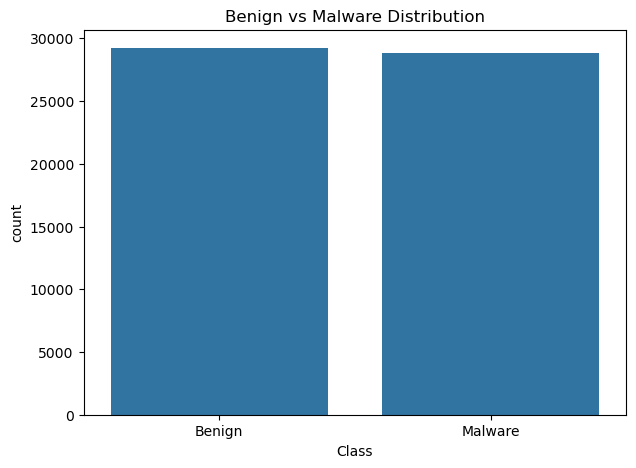

In [4]:
# ----------------------------------------------------------
#  Benign vs Malware Count
# ----------------------------------------------------------
plt.figure(figsize=(7,5))
sns.countplot(x="Class", data=df)
plt.title("Benign vs Malware Distribution")
plt.show()


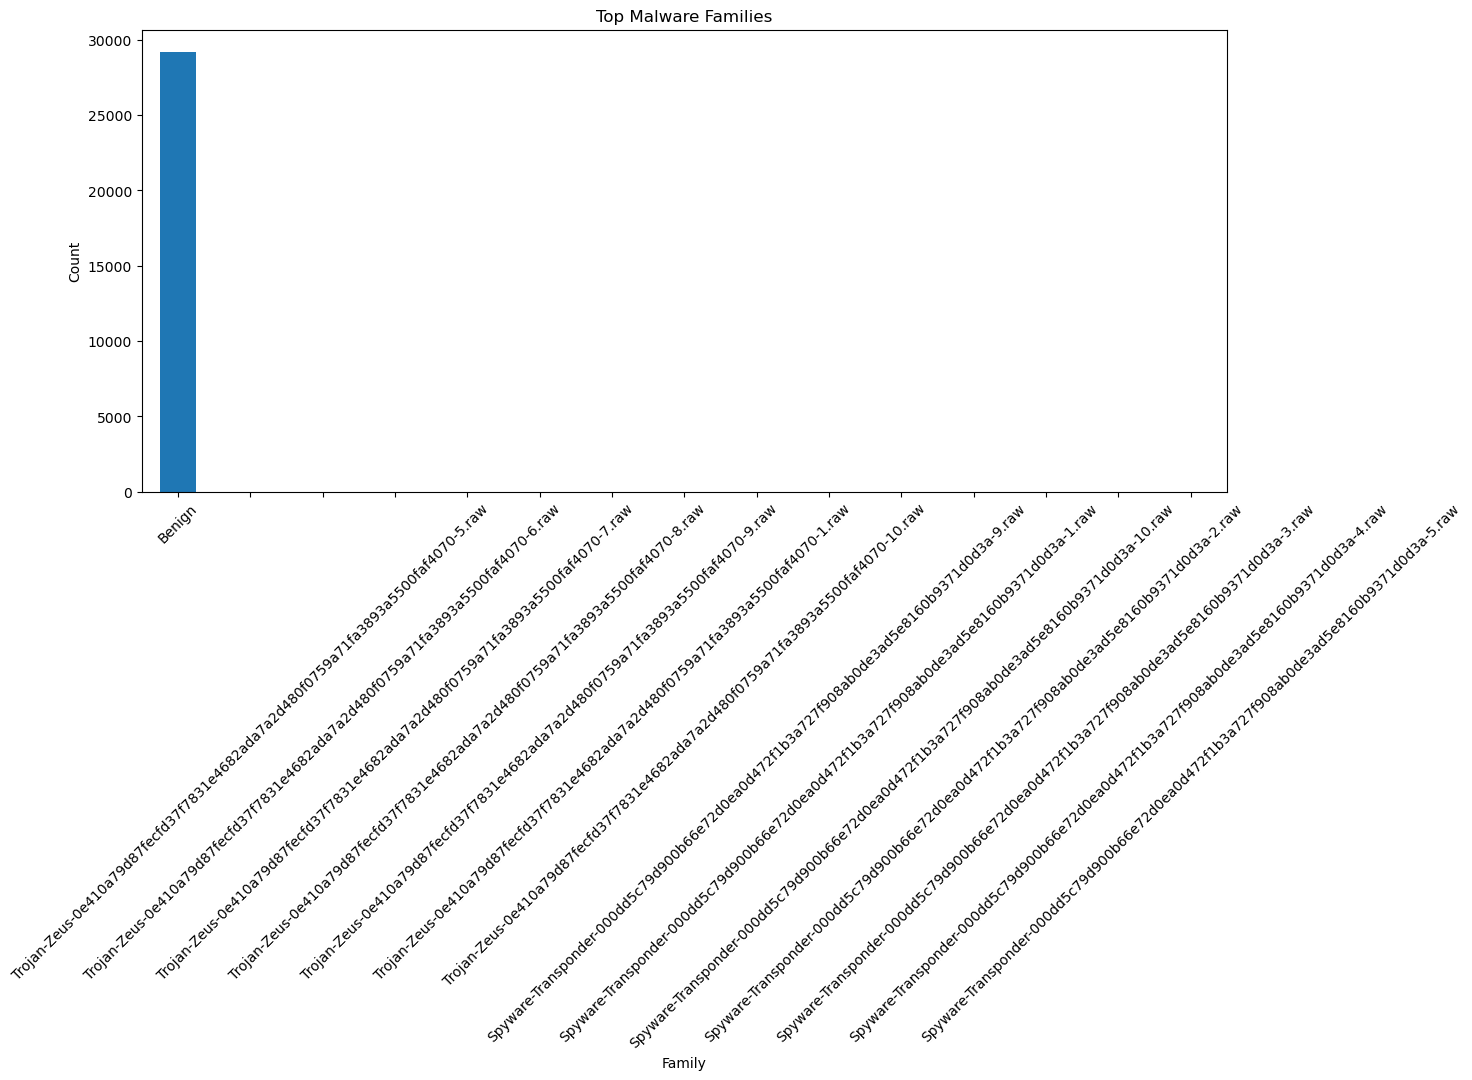

In [5]:
# ----------------------------------------------------------
# Malware Family Distribution
# ----------------------------------------------------------
plt.figure(figsize=(14,6))
df["Category"].value_counts().head(15).plot(kind="bar")
plt.title("Top Malware Families")
plt.xlabel("Family")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

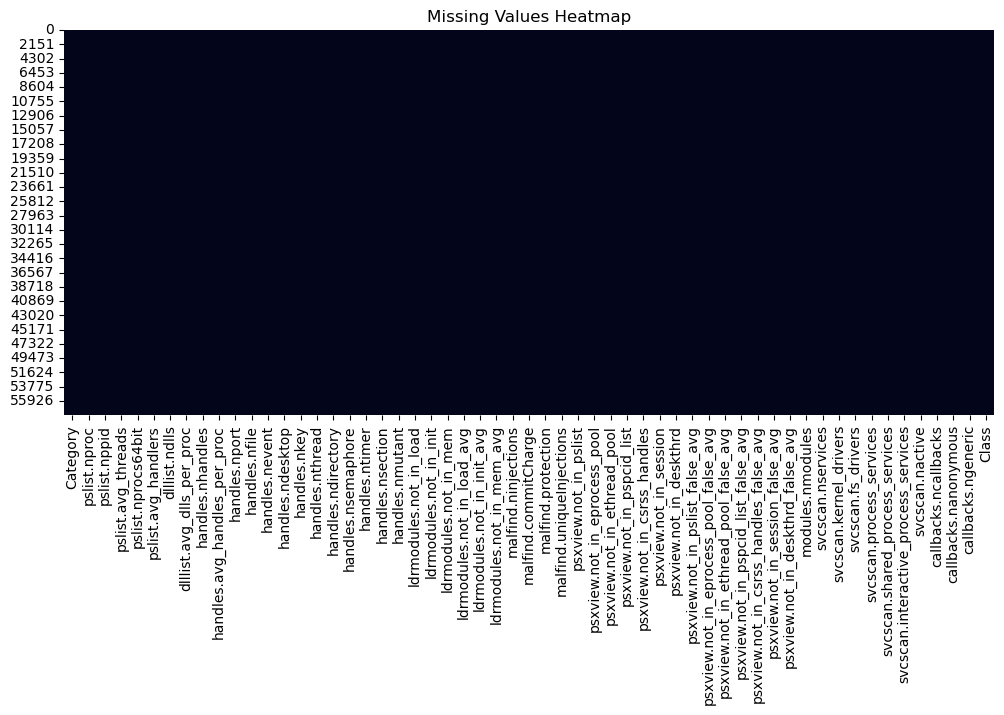

In [6]:
# ----------------------------------------------------------
# Missing Values Heatmap
# ----------------------------------------------------------
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

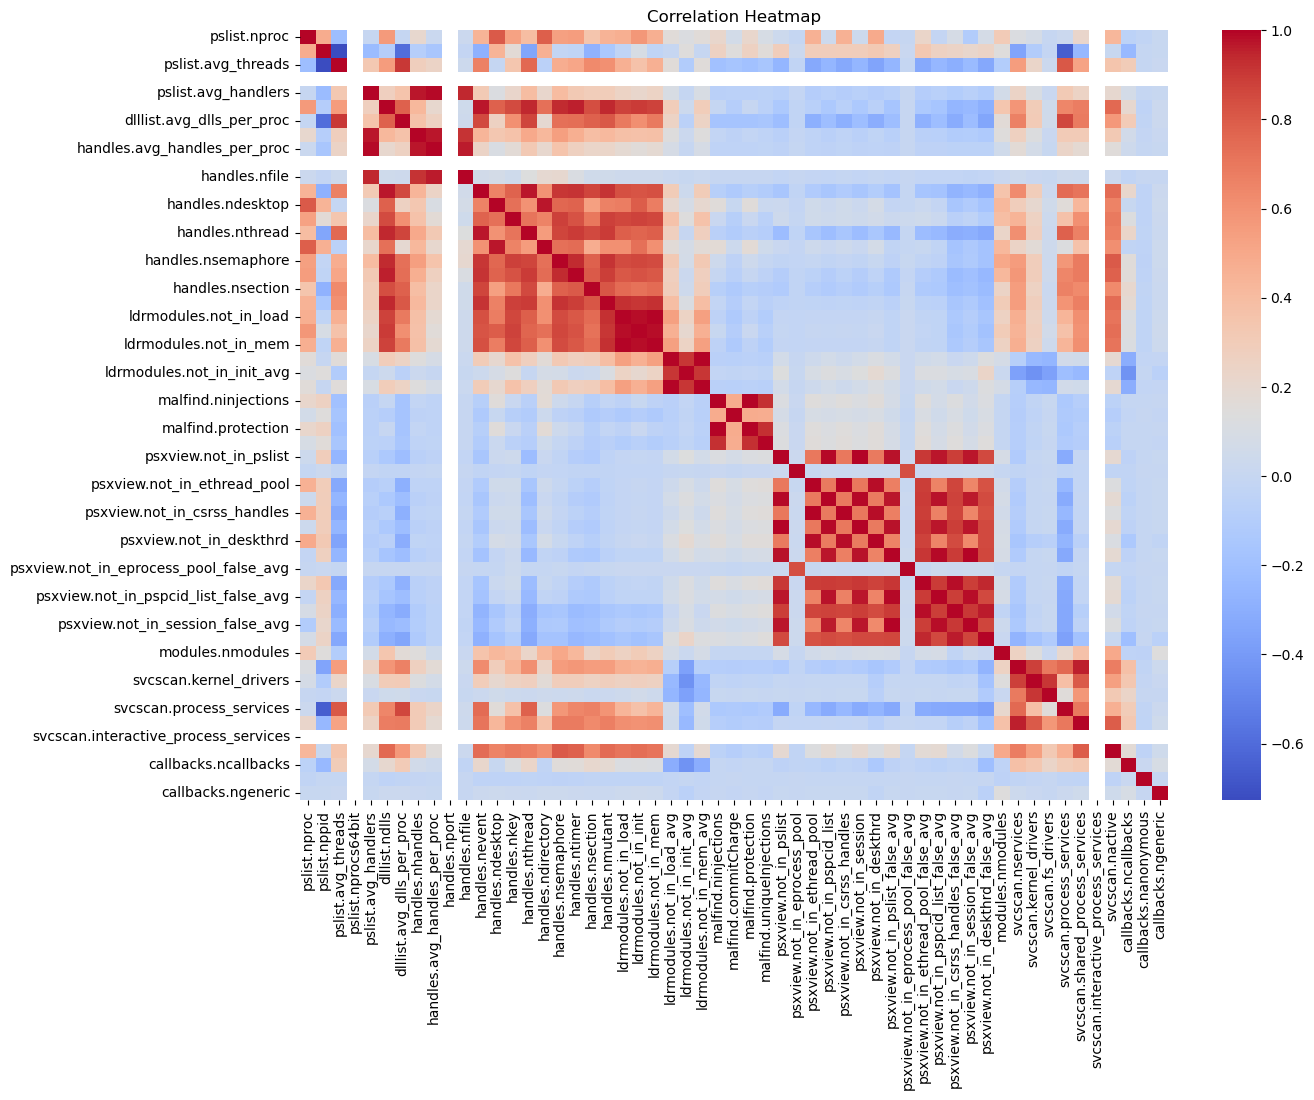

In [7]:
# ----------------------------------------------------------
# Correlation Heatmap
# ----------------------------------------------------------
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

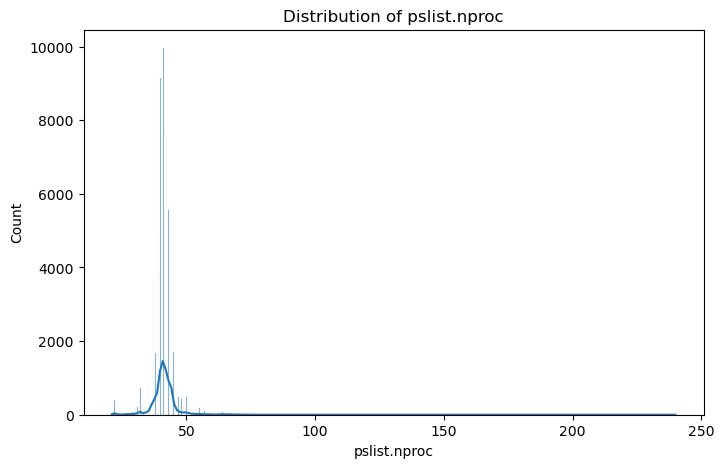

In [8]:
# ----------------------------------------------------------
# Histogram of First Feature
# ----------------------------------------------------------
first_col = numeric_df.columns[0]

plt.figure(figsize=(8,5))
sns.histplot(df[first_col], kde=True)
plt.title(f"Distribution of {first_col}")
plt.show()

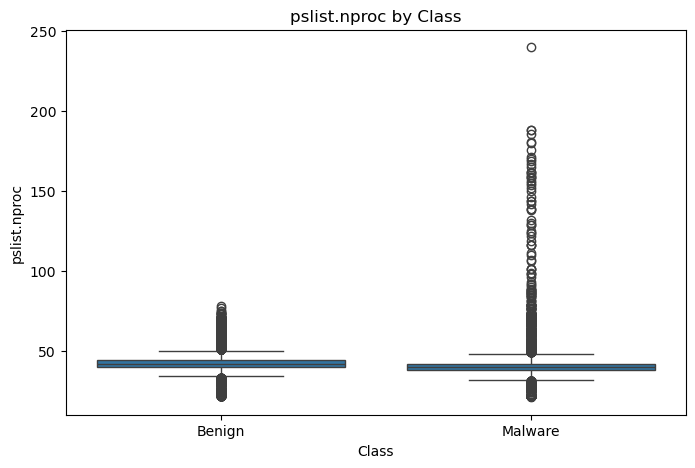

In [9]:
# ----------------------------------------------------------
# Boxplot by Class
# ----------------------------------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y=first_col, data=df)
plt.title(f"{first_col} by Class")
plt.show()

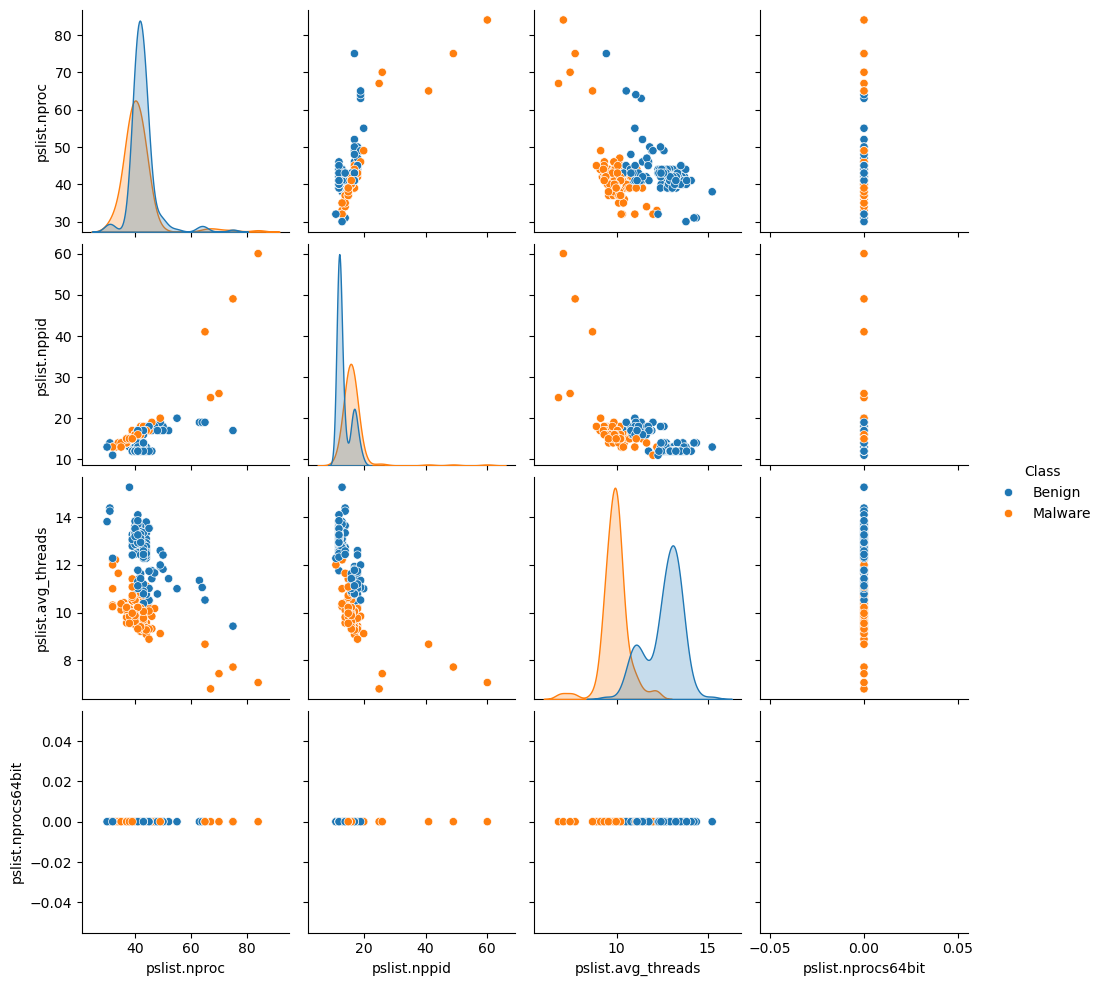

In [10]:
# ----------------------------------------------------------
# Pairplot Sample
# ----------------------------------------------------------
sample_df = df.sample(300, random_state=42)

pair_cols = list(numeric_df.columns[:4])
sns.pairplot(sample_df[pair_cols + ["Class"]], hue="Class")
plt.show()

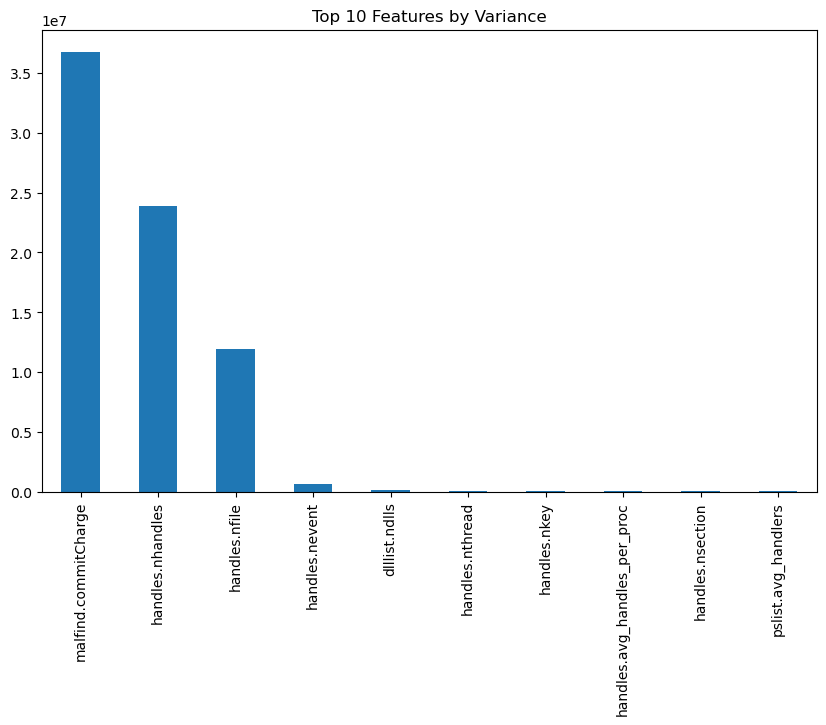

In [11]:
# ----------------------------------------------------------
# Variance of Top Features
# ----------------------------------------------------------
variance = numeric_df.var().sort_values(ascending=False)

plt.figure(figsize=(10,6))
variance.head(10).plot(kind="bar")
plt.title("Top 10 Features by Variance")
plt.show()

In [12]:
# ==========================================================
# 4. PREPROCESSING
# ==========================================================
df = df.dropna()

# Encode Target
le = LabelEncoder()
df["Class"] = le.fit_transform(df["Class"])   # Benign=0 Malware=1

# Features & Target
X = df.drop(["Class", "Category"], axis=1)
y = df["Class"]

In [13]:
# ==========================================================
# 5. TRAIN TEST SPLIT
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [14]:
# ==========================================================
# 6. HANDLE IMBALANCE
# ==========================================================
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train).value_counts())


After SMOTE:
Class
1    23381
0    23381
Name: count, dtype: int64


In [15]:
# ==========================================================
# 7. MODELS
# ==========================================================
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

results = []

In [16]:
# ==========================================================
# 8. TRAIN & EVALUATE
# ==========================================================
for name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc = roc_auc_score(y_test, prob)

    results.append([name, acc, prec, rec, f1, roc])

    print("\n===================================")
    print(name)
    print("===================================")
    print(classification_report(y_test, pred))


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5846
           1       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612


Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5846
           1       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5846
           1       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00

In [17]:
# ==========================================================
# 9. RESULTS TABLE
# ==========================================================
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"
])

print("\nFinal Results:")
print(results_df)

results_df.to_csv("final_model_results.csv", index=False)


Final Results:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0        Random Forest  1.000000   1.000000  1.000000  1.000000  1.000000
1        Decision Tree  1.000000   1.000000  1.000000  1.000000  1.000000
2  Logistic Regression  0.999139   0.999306  0.998959  0.999133  0.999998
3                  SVM  0.999656   0.999653  0.999653  0.999653  1.000000
4              XGBoost  1.000000   1.000000  1.000000  1.000000  1.000000


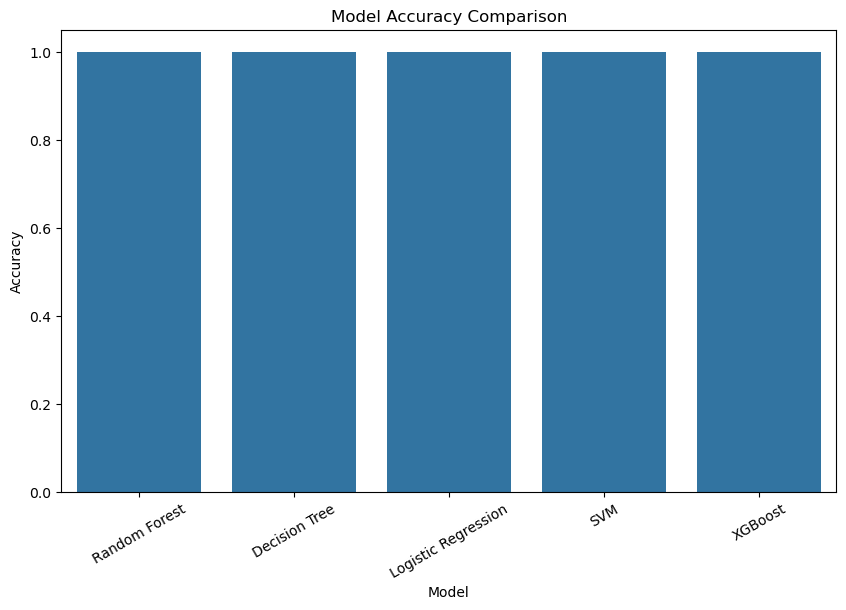

In [18]:
# ==========================================================
# 10. ACCURACY COMPARISON
# ==========================================================
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

In [19]:
# ==========================================================
# 11. BEST MODEL = XGBoost
# ==========================================================
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(eval_metric='logloss'))
])

best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)
prob = best_model.predict_proba(X_test)[:,1]

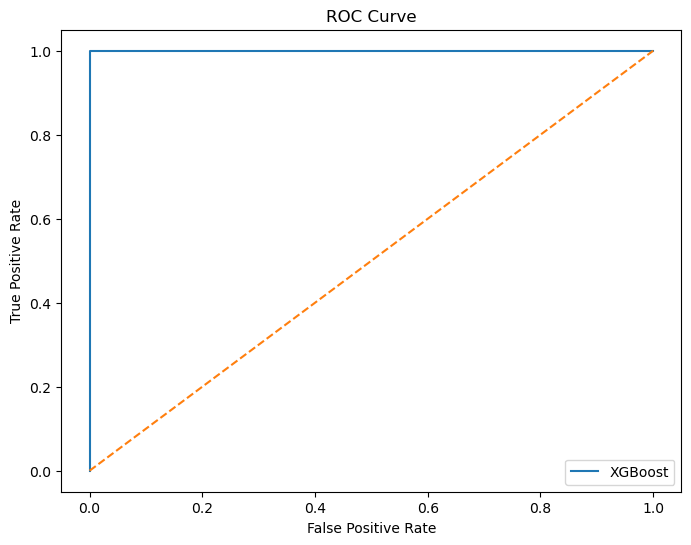

In [20]:
# ==========================================================
# 12. ROC CURVE
# ==========================================================
fpr, tpr, thresholds = roc_curve(y_test, prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

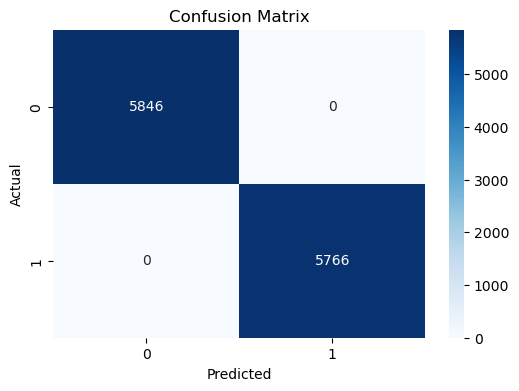

In [21]:
# ==========================================================
# 13. CONFUSION MATRIX
# ==========================================================
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
# ==========================================================
# 14. CROSS VALIDATION
# ==========================================================
cv_scores = cross_val_score(best_model, X, y, cv=5)

print("\nCross Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())


Cross Validation Scores: [0.99982776 0.99991388 0.99483293 0.99879425 1.        ]
Mean CV Score: 0.9986737649715266



Top 10 Important Features:
                         Feature  Importance
45             svcscan.nservices    0.975343
48      svcscan.process_services    0.008891
8   handles.avg_handles_per_proc    0.003345
7               handles.nhandles    0.002493
52          callbacks.ncallbacks    0.001632
12              handles.ndesktop    0.001370
27          malfind.commitCharge    0.000738
32   psxview.not_in_ethread_pool    0.000622
26           malfind.ninjections    0.000500
36       psxview.not_in_deskthrd    0.000452


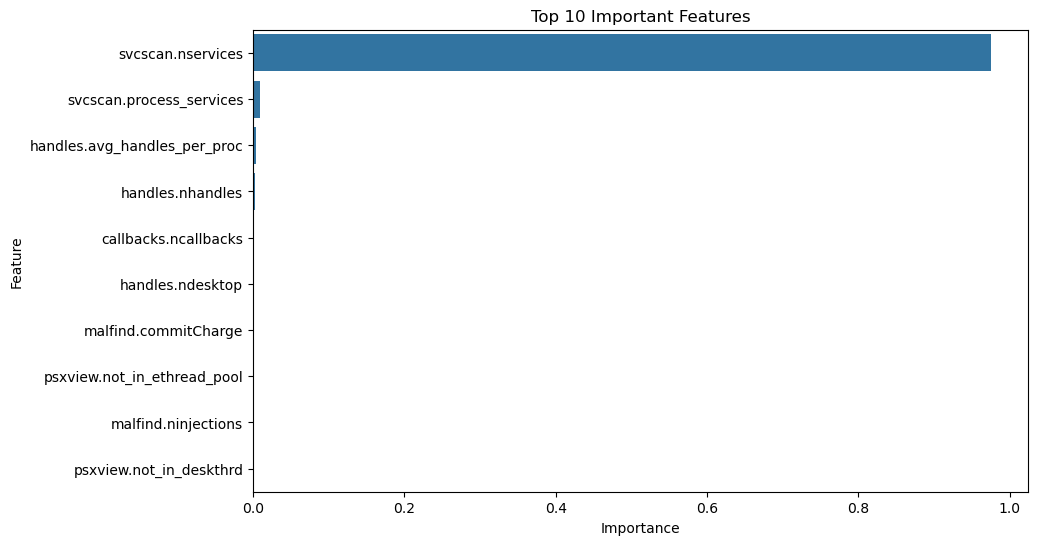

In [23]:
# ==========================================================
# 15. FEATURE IMPORTANCE
# ==========================================================
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))

plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)
plt.title("Top 10 Important Features")
plt.show()